# Delinquency Prediction — All Consumers (`q2-ucsd-consDF.pqt`)

End-to-end pipeline that produces a **continuous delinquency probability** for every consumer in `q2-ucsd-consDF.pqt`, plus **3 SHAP-based reasons** for each predicted defaulter.

**Steps:**
1. **Feature Creation** — build the same feature matrix used in the labeled pipeline for untagged consumers
2. **Scoring Exclusions** — remove consumers who don't meet minimum data quality thresholds  
3. **Feature Selection** — reuse the consensus-ordered feature ranking
4. **XGBoost Training** — train on the **full** `filtered_features_consensus_ordered.csv` (no holdout); Optuna tunes hyperparameters via 5-fold cross-validation
5. **Scoring** — apply the trained model to ALL consumers from `q2-ucsd-consDF.pqt`; output continuous `dq_probability`
6. **SHAP Explanations** — for each predicted defaulter, extract the top-3 features most responsible for the default score

In [28]:
import sys
import pathlib
import os

project_root = str(pathlib.Path('..').resolve())
if project_root not in sys.path:
    sys.path.insert(0, project_root)

import pandas as pd
import numpy as np
import xgboost as xgb
import shap
import matplotlib.pyplot as plt
import time
import warnings
warnings.filterwarnings('ignore')

from scripts.data_loading import accounts, transactions, category_mapping
from scripts.feature_selection import load_features
from scripts.feature_creation import (
    prepare_daily_data,
    create_balance_features,
    create_daily_window_features,
    create_transaction_features,
    create_category_features,
    create_group_category_features,
    create_overdraft_fee_features,
    create_low_balance_risk_features,
    create_income_regularity_features,
    create_paycheck_to_paycheck_features,
    create_multi_account_features,
)

## 1. Feature Creation for Untagged Consumers

Build the same transaction-based feature matrix used in the labeled pipeline, but for the consumers whose `DQ_TARGET` is unknown.

In [29]:
# ── Configuration ─────────────────────────────────────────────────────────────
N_FEATURES    = 50
FEATURES_FILE = "filtered_features_consensus_ordered.csv"
OUTPUT_DIR    = pathlib.Path('..') / 'output'
UNTAGGED_CSV  = OUTPUT_DIR / 'untagged_consumers.csv'
BACKFILL_CSV  = OUTPUT_DIR / 'feature_creation_backfill_df.csv'

# Load untagged consumer list
untagged_df  = pd.read_csv(UNTAGGED_CSV)
untagged_ids = set(untagged_df['prism_consumer_id'].unique())

print(f"Untagged consumers: {len(untagged_ids)}")
print(untagged_df.head())

# Filter raw tables to only untagged consumers
accounts_unt     = accounts[accounts['prism_consumer_id'].isin(untagged_ids)].copy()
transactions_unt = transactions[transactions['prism_consumer_id'].isin(untagged_ids)].copy()

print(f"\nAccount rows    : {len(accounts_unt):,}")
print(f"Transaction rows: {len(transactions_unt):,}")

Untagged consumers: 3000
   prism_consumer_id evaluation_date  credit_score  DQ_TARGET
0               4000      2021-09-01         773.0        NaN
1               4001      2021-10-01         643.0        NaN
2               4002      2021-12-01         734.0        NaN
3               4003      2021-12-01         661.0        NaN
4               4004      2021-10-01         802.0        NaN

Account rows    : 0
Transaction rows: 0


### 1a. Load Running-Balance Backfill

Use the pre-computed `feature_creation_backfill_df.csv` (built by `feature_engineering/feature_creation.ipynb` over all consumers). Filter it to the untagged consumer IDs so we can build their features. This avoids having to rebuild the running balances from scratch and handles cases where `accounts` or `transactions` may miss some consumer IDs.

In [30]:
# ── Load the pre-computed backfill (covers ALL consumers, DQ_TARGET=NaN for untagged) ──
if BACKFILL_CSV.exists():
    full_backfill = pd.read_csv(BACKFILL_CSV)
    print(f"Loaded pre-computed backfill: {len(full_backfill):,} rows, "
          f"{full_backfill['prism_consumer_id'].nunique():,} unique consumers")
else:
    from scripts.backfill_transactions import build_backfill_df
    print("Pre-computed backfill not found — rebuilding from scratch (slow) …")
    full_backfill = build_backfill_df()
    print(f"Built backfill: {len(full_backfill):,} rows")

# Filter to untagged consumer IDs
backfill_df = full_backfill[full_backfill['prism_consumer_id'].isin(untagged_ids)].copy()
backfill_df['date'] = pd.to_datetime(backfill_df['date'])

print(f"\nUntagged consumer backfill rows  : {len(backfill_df):,}")
print(f"Unique untagged consumers found  : {backfill_df['prism_consumer_id'].nunique():,}")
missing = untagged_ids - set(backfill_df['prism_consumer_id'])
if missing:
    print(f"Untagged IDs not in backfill     : {len(missing)} (will be scored as NaN)")
backfill_df.head()

Loaded pre-computed backfill: 5,211,275 rows, 12,900 unique consumers

Untagged consumer backfill rows  : 1,029,131
Unique untagged consumers found  : 2,583
Untagged IDs not in backfill     : 417 (will be scored as NaN)


,prism_consumer_id,date,balance,credit_or_debit,amount_change,DQ_TARGET
206,4416,2022-03-31,66.42,starting value,0.00,NaN
207,4416,2021-10-15,66.76,CREDIT,0.34,NaN
208,4416,2021-10-15,66.82,CREDIT,0.06,NaN
209,4416,2021-10-16,106.82,CREDIT,40.00,NaN
210,4416,2021-10-16,156.82,CREDIT,50.00,NaN


### 1b. Load Features from CSV

Load the pre-computed feature matrix from `features.csv` and filter to untagged consumer IDs.


In [31]:
features_path = OUTPUT_DIR / 'features.csv'
full_features = pd.read_csv(features_path, index_col='prism_consumer_id')
full_features = full_features[~full_features.index.duplicated(keep='first')]

X_unt = full_features[full_features.index.isin(untagged_ids)].copy()
X_unt = X_unt.drop(columns=['DQ_TARGET'], errors='ignore')
X_unt = X_unt.replace([np.inf, -np.inf], np.nan)

print(f"Loaded features from {features_path.name}: {full_features.shape} (after dedup)")
print(f"Untagged feature matrix: {X_unt.shape}")

X_unt.head() if len(X_unt) else print("(empty)")


Loaded features from features.csv: (14854, 237) (after dedup)
Untagged feature matrix: (2967, 236)


,balance__mean__all,balance__median__all,balance__min__all,balance__max__all,balance__std__all,balance__pct_negative__all,balance__pct_below_100__all,balance__pct_below_500__all,n_days__all,account__history_days__all,...,credit_card__n_accounts,revolving_debt__balance__latest,revolving_debt__balance__mean,revolving_debt__n_accounts,longterm_debt__balance__total,longterm_debt__balance__mean,longterm_debt__n_accounts,net_liquid_position__all_accounts,total_debt__all_accounts,savings_to_debt_ratio
prism_consumer_id,,,,,,,,,,,,,,,,,,,,,
4000,28600.578491,28685.69,21982.83,38090.32,3660.412165,0.000000,0.000000,0.000000,53.0,179.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4001,933.685455,1053.52,-123.98,2087.07,606.632177,0.049587,0.123967,0.314050,121.0,176.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4002,-261852.230137,-288646.76,-364946.90,61164.00,124673.763885,0.876712,0.876712,0.876712,73.0,180.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4003,1095.402542,994.79,-169.10,2975.05,780.611097,0.028249,0.067797,0.265537,177.0,180.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4004,-4610.735385,-4416.60,-8308.71,2991.72,2309.315091,0.984615,0.984615,0.984615,130.0,179.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 2. Scoring Exclusions

Apply the same data-quality gates as in `scoring_exclusions/scoring_exclusions.ipynb`:
- **Rule 1** — minimum total transactions ≥ 10
- **Rule 2** — minimum account history ≥ 20 days
- **Rule 3** — minimum income frequency ≥ 2 events / 90 days

In [32]:
X_unt['income__frequency__90d'].value_counts(dropna=False)

income__frequency__90d
NaN         2593
0.122222      25
0.166667      21
0.177778      19
0.155556      19
0.133333      16
0.144444      16
0.000000      16
0.233333      16
0.211111      15
0.222222      14
0.088889      14
0.111111      14
0.100000      13
0.200000      13
0.188889      12
0.077778      10
0.044444       8
0.300000       8
0.022222       8
0.266667       7
0.311111       7
0.033333       6
0.055556       6
0.066667       5
0.288889       5
0.355556       5
0.244444       5
0.255556       5
0.366667       5
0.277778       4
0.333333       4
0.322222       4
0.466667       3
0.433333       2
0.344444       2
0.377778       2
0.388889       2
0.644444       1
0.844444       1
0.455556       1
0.611111       1
0.722222       1
0.522222       1
0.477778       1
0.511111       1
0.400000       1
1.111111       1
0.555556       1
0.444444       1
0.422222       1
0.744444       1
0.500000       1
1.177778       1
0.544444       1
0.566667       1
Name: count, dtype: int64

In [33]:
X_unt.shape[0]

2967

In [34]:
df_work = X_unt.copy()
start_total = len(df_work)

MIN_TX          = 10
MIN_DAYS        = 20
MIN_INCOME_FREQ = 2 / 90

def col_lt(df, col, threshold):
    """Return a boolean Series: True where col < threshold, or True where col is missing entirely."""
    if col not in df.columns:
        print(f"  Note: column '{col}' not found — treating all rows as excluded by this rule")
        return pd.Series(True, index=df.index)
    return df[col].lt(threshold).fillna(True)

exclusion_masks = {}
exclusion_masks['rule_min_tx']          = col_lt(df_work, 'tx__n__all',             MIN_TX)
exclusion_masks['rule_min_days']        = col_lt(df_work, 'account__history_days__all', MIN_DAYS)
exclusion_masks['rule_income_presence'] = col_lt(df_work, 'income__frequency__90d', MIN_INCOME_FREQ)

combined_mask = pd.concat(exclusion_masks.values(), axis=1).any(axis=1)
df_scored = df_work.loc[~combined_mask].copy()

print("----- EXCLUSION SUMMARY -----")
print(f"Started with : {start_total}")
for rule, mask in exclusion_masks.items():
    print(f"  {rule}: {int(mask.sum())} flagged")
print(f"Combined removed: {int(combined_mask.sum())} ({combined_mask.mean():.1%})")
print(f"Remaining for scoring: {len(df_scored)}")

----- EXCLUSION SUMMARY -----
Started with : 2967
  rule_min_tx: 186 flagged
  rule_min_days: 144 flagged
  rule_income_presence: 24 flagged
Combined removed: 223 (7.5%)
Remaining for scoring: 2744


In [35]:

# DIAGNOSTIC — delete after debugging
print(f"X_unt shape: {X_unt.shape}")
print(f"df_work shape: {df_work.shape}")
for col in ['tx__n__all', 'account__history_days__all']:
    if col in X_unt.columns:
        print(f"\n{col}:")
        print(X_unt[col].describe())
        print(f"  NaN count: {X_unt[col].isna().sum()}")
        print(f"  Count below threshold: {(X_unt[col] < (10 if 'tx' in col else 20)).sum()}")
    else:
        print(f"\n{col}: COLUMN NOT FOUND IN X_unt!")
print(f"\ncombined_mask True count: {combined_mask.sum()} / {len(combined_mask)}")


X_unt shape: (2967, 236)
df_work shape: (2967, 236)

tx__n__all:
count    2583.000000
mean      398.424700
std       386.301033
min         1.000000
25%       146.000000
50%       319.000000
75%       524.000000
max      5528.000000
Name: tx__n__all, dtype: float64
  NaN count: 384
  Count below threshold: 186

account__history_days__all:
count    2583.000000
mean      147.092141
std        76.850530
min         0.000000
25%        88.000000
50%       175.000000
75%       180.000000
max       716.000000
Name: account__history_days__all, dtype: float64
  NaN count: 384
  Count below threshold: 144

combined_mask True count: 223 / 2967


## 3. Feature Selection

Load the consensus-ordered feature ranking produced by the feature-selection pipeline and select the same top-N features used during model training.

In [36]:
# Load the pre-ranked feature list from the labeled pipeline
ranked_df = pd.read_csv(OUTPUT_DIR / FEATURES_FILE, index_col=0, nrows=0)
ranked_features = [c for c in ranked_df.columns if c != 'DQ_TARGET']
selected_features = ranked_features[:N_FEATURES]

print(f"Total ranked features : {len(ranked_features)}")
print(f"Selected (top-{N_FEATURES})  : {len(selected_features)}")

# Align df_scored to those features (fill missing columns with 0)
missing_cols = [f for f in selected_features if f not in df_scored.columns]
if missing_cols:
    print(f"\nWarning: {len(missing_cols)} selected features absent in untagged data — will be filled with 0:")
    print(missing_cols[:10])

X_untagged = df_scored.reindex(columns=selected_features).fillna(0).values
consumer_ids_scored = df_scored.index.tolist()

print(f"\nScoring matrix shape: {X_untagged.shape}")

Total ranked features : 235
Selected (top-50)  : 50

Scoring matrix shape: (2744, 50)


## 4. Train XGBoost on Full Labeled Data

Train on **all** rows from `filtered_features_consensus_ordered.csv` using the same fixed hyperparameters as `model_comparison.ipynb`. The untagged consumers (`X_unt` after exclusions) serve as the prediction target.


In [37]:
# Load the full labeled feature matrix (no holdout split)
features_df, ranked_features = load_features(features_filename=FEATURES_FILE)

# Use the same top-N features selected in Section 3
available_features = selected_features   # defined in Section 3

labeled_clean = features_df[features_df['DQ_TARGET'].notna()].copy()
y_all = labeled_clean['DQ_TARGET'].astype(int).values
X_all = labeled_clean[available_features].fillna(0).values

dq_rate = y_all.mean()
print(f'Features      : {len(available_features)}')
print(f'Labeled rows  : {X_all.shape[0]}  |  DQ rate: {dq_rate:.2%}  |  Positives: {y_all.sum()}')

Features      : 50
Labeled rows  : 9277  |  DQ rate: 8.70%  |  Positives: 807


In [38]:
# Class-imbalance weight
n_neg = int(np.sum(y_all == 0))
n_pos = int(np.sum(y_all == 1))
scale_pos_weight = n_neg / n_pos
print(f'scale_pos_weight: {scale_pos_weight:.2f}  (neg={n_neg}, pos={n_pos})')

dtrain = xgb.DMatrix(X_all,      label=y_all,  feature_names=list(available_features))
dtest  = xgb.DMatrix(X_untagged,               feature_names=list(available_features))
print(f'DMatrix train   : {X_all.shape}')
print(f'DMatrix test    : {X_untagged.shape}  (untagged consumers after exclusions)')


scale_pos_weight: 10.50  (neg=8470, pos=807)
DMatrix train   : (9277, 50)
DMatrix test    : (2744, 50)  (untagged consumers after exclusions)


In [39]:
params = {
    'objective':        'binary:logistic',
    'eval_metric':      'auc',
    'max_depth':        5,
    'learning_rate':    0.05,
    'subsample':        0.8,
    'colsample_bytree': 0.8,
    'min_child_weight': 5,
    'scale_pos_weight': scale_pos_weight,
    'seed':             42,
    'verbosity':        0,
}

t0 = time.time()
booster = xgb.train(
    params,
    dtrain,
    num_boost_round=500,
    evals=[(dtrain, 'train')],
    verbose_eval=50,
)
training_time = time.time() - t0
print(f'\nTraining completed in {training_time:.2f}s  |  500 trees')


[0]	train-auc:0.81590
[50]	train-auc:0.91820
[100]	train-auc:0.95693
[150]	train-auc:0.97437
[200]	train-auc:0.98493
[250]	train-auc:0.99236
[300]	train-auc:0.99608
[350]	train-auc:0.99804
[400]	train-auc:0.99907
[450]	train-auc:0.99946
[499]	train-auc:0.99976

Training completed in 1.01s  |  500 trees


## 5. Score Untagged Consumers

Apply the trained booster to the untagged consumer feature matrix (`dtest`) to produce a **continuous `dq_probability`** for each consumer.


In [40]:
t_score    = time.time()
pred_proba = booster.predict(dtest)
score_time = time.time() - t_score

print(f'Scored {len(pred_proba)} untagged consumers in {score_time*1000:.1f} ms')
print(f'dq_probability — min: {pred_proba.min():.4f}  '
      f'max: {pred_proba.max():.4f}  mean: {pred_proba.mean():.4f}')
print(f'\nHigh-risk (prob >= 0.5) : {(pred_proba >= 0.5).sum()}')


Scored 2744 untagged consumers in 3.0 ms
dq_probability — min: 0.0008  max: 0.9231  mean: 0.1579

High-risk (prob >= 0.5) : 306


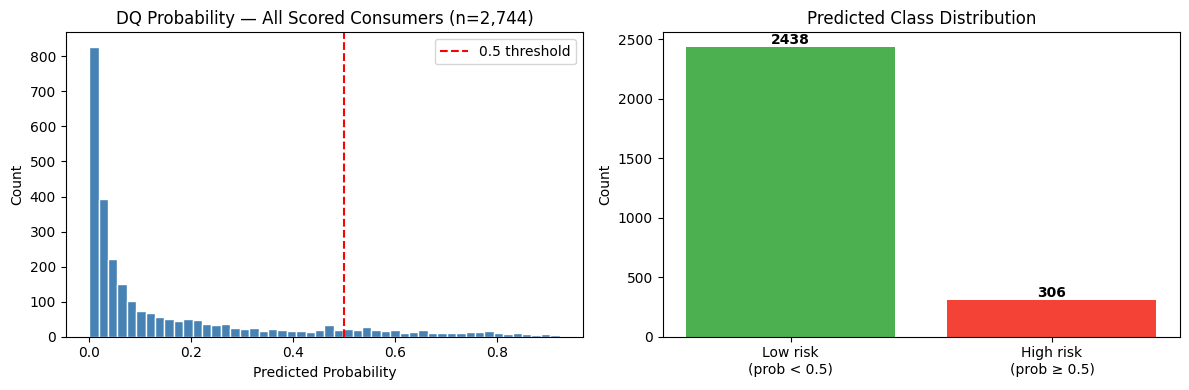

In [41]:
# ── Distribution of predicted probabilities ───────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(pred_proba, bins=50, color='steelblue', edgecolor='white')
axes[0].axvline(0.5, color='red', linestyle='--', label='0.5 threshold')
axes[0].set_title(f'DQ Probability — All Scored Consumers (n={len(pred_proba):,})')
axes[0].set_xlabel('Predicted Probability')
axes[0].set_ylabel('Count')
axes[0].legend()

high_risk  = (pred_proba >= 0.5).sum()
low_risk   = (pred_proba <  0.5).sum()
axes[1].bar(['Low risk\n(prob < 0.5)', 'High risk\n(prob ≥ 0.5)'],
            [low_risk, high_risk],
            color=['#4CAF50', '#F44336'])
axes[1].set_title('Predicted Class Distribution')
axes[1].set_ylabel('Count')
for ax, cnt in zip(axes[1].patches, [low_risk, high_risk]):
    axes[1].text(ax.get_x() + ax.get_width() / 2, ax.get_height() + 1,
                 str(cnt), ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

## 6. SHAP Explanations — Top-3 Reasons per Predicted Defaulter

Use `shap.TreeExplainer` on the booster to compute per-consumer SHAP values.  
For each consumer predicted as a **defaulter** (probability ≥ 0.5), the **3 features with the largest positive SHAP contribution** (i.e., features that most increased the default risk) are recorded as `reason_1 / reason_2 / reason_3`.

We also show the global SHAP feature importance (mean |SHAP|).

Computing SHAP values …
Done in 0.4s


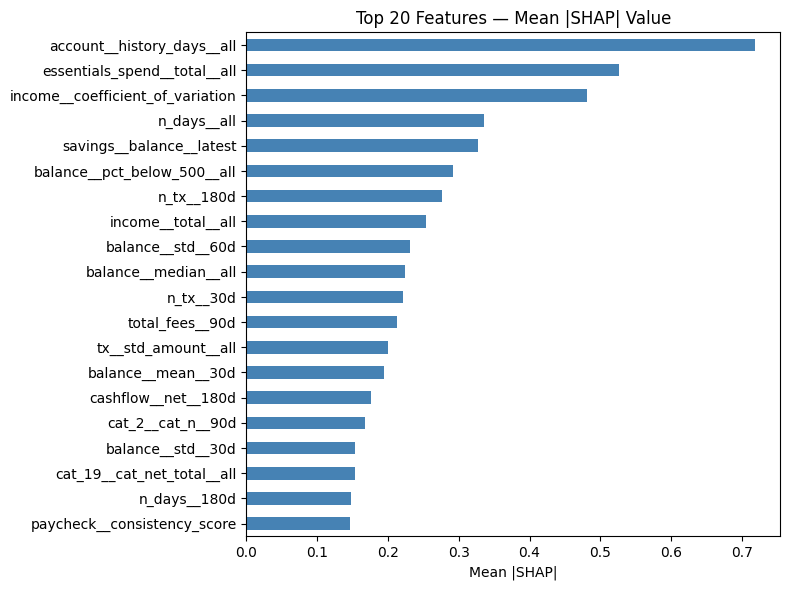

account__history_days__all          0.718062
essentials_spend__total__all        0.525873
income__coefficient_of_variation    0.480960
n_days__all                         0.336323
savings__balance__latest            0.326892
balance__pct_below_500__all         0.291871
n_tx__180d                          0.275833
income__total__all                  0.253311
balance__std__60d                   0.230608
balance__median__all                0.223707
n_tx__30d                           0.221220
total_fees__90d                     0.212065
tx__std_amount__all                 0.200088
balance__mean__30d                  0.194922
cashflow__net__180d                 0.175432
cat_2__cat_n__90d                   0.167189
balance__std__30d                   0.154006
cat_19__cat_net_total__all          0.153919
n_days__180d                        0.147651
paycheck__consistency_score         0.146794
dtype: float32

In [42]:
print('Computing SHAP values …')
t_shap = time.time()
explainer   = shap.TreeExplainer(booster)
shap_values = explainer.shap_values(X_untagged)   # shape: (n_consumers, n_features)
print(f'Done in {time.time()-t_shap:.1f}s')

# Some SHAP versions return a list [neg_class, pos_class] for binary classifiers
if isinstance(shap_values, list):
    shap_values = shap_values[1]

shap_df = pd.DataFrame(
    shap_values,
    index=consumer_ids_scored,
    columns=available_features,
)
shap_df.index.name = 'prism_consumer_id'

# ── Global feature importance (mean |SHAP|) ────────────────────
mean_abs_shap = shap_df.abs().mean().sort_values(ascending=False).head(20)

fig, ax = plt.subplots(figsize=(8, 6))
mean_abs_shap.plot(kind='barh', ax=ax, color='steelblue')
ax.invert_yaxis()
ax.set_title('Top 20 Features — Mean |SHAP| Value')
ax.set_xlabel('Mean |SHAP|')
plt.tight_layout()
plt.show()

mean_abs_shap


## 7. Attach SHAP Reasons & Save

For each consumer, extract the top-3 features with the **highest positive SHAP value** (the features most responsible for pushing the score toward default).  
`reason_1/2/3` contain the feature name followed by its SHAP contribution in brackets, e.g. `balance__pct_negative__all (+0.312)`.  
For consumers below the 0.5 threshold the reason columns are blank.

In [43]:
DQ_THRESHOLD = 0.5

def top_positive_shap(shap_row, n=3):
    """Return top-n feature names by descending positive SHAP value."""
    pos = shap_row[shap_row > 0].sort_values(ascending=False)
    top = pos.head(n)
    return [f"{feat} (+{val:.3f})" for feat, val in top.items()] + [''] * max(0, n - len(top))

reasons_raw = shap_df.apply(top_positive_shap, axis=1, result_type='expand')
reasons_raw.columns = ['reason_1', 'reason_2', 'reason_3']

# Build scored df from scratch using consumer_ids_scored and pred_proba
scored = pd.DataFrame({
    'prism_consumer_id': consumer_ids_scored,
    'dq_probability':    pred_proba.round(6),
}).set_index('prism_consumer_id')

scored = scored.join(reasons_raw, how='left')

# Zero-out reasons for non-defaulters
mask_non_default = scored['dq_probability'] < DQ_THRESHOLD
scored.loc[mask_non_default, ['reason_1', 'reason_2', 'reason_3']] = ''
scored = scored.reset_index()

# ── Expand to all 3000 untagged consumers (include excluded ones with NaN score) ──
results_df = (
    untagged_df[['prism_consumer_id']]
    .merge(scored, on='prism_consumer_id', how='left')
)
results_df[['reason_1', 'reason_2', 'reason_3']] = results_df[['reason_1', 'reason_2', 'reason_3']].fillna('')

results_df = results_df.sort_values('dq_probability', ascending=False).reset_index(drop=True)

# ── Save ──────────────────────────────────────────────────────────
out_path = pathlib.Path('..') / 'output' / 'consumer_dq_predictions.csv'
results_df.to_csv(out_path, index=False)
print(f'Saved {len(results_df)} consumer scores to {out_path}')
print(f'  Scored (with dq_probability)  : {results_df["dq_probability"].notna().sum()}')
print(f'  Excluded (dq_probability=NaN) : {results_df["dq_probability"].isna().sum()}')

# ── Preview ───────────────────────────────────────────────────────
n_default = (results_df['dq_probability'] >= DQ_THRESHOLD).sum()
print(f'\nPredicted defaulters (prob >= {DQ_THRESHOLD}): {n_default} / {results_df["dq_probability"].notna().sum()} scored')
results_df.head(15)


Saved 3000 consumer scores to ..\output\consumer_dq_predictions.csv
  Scored (with dq_probability)  : 2744
  Excluded (dq_probability=NaN) : 256

Predicted defaulters (prob >= 0.5): 306 / 2744 scored


,prism_consumer_id,dq_probability,reason_1,reason_2,reason_3
0,9668,0.923086,account__history_days__all (+0.539),n_days__all (+0.513),balance__pct_below_500__all (+0.352)
1,9215,0.921863,account__history_days__all (+0.591),n_days__all (+0.408),balance__std__30d (+0.400)
2,9308,0.915711,account__history_days__all (+0.823),n_days__all (+0.503),balance__pct_below_500__all (+0.440)
3,9793,0.911908,account__history_days__all (+0.911),n_days__all (+0.502),balance__pct_below_500__all (+0.387)
4,9788,0.906414,account__history_days__all (+0.990),n_days__all (+0.561),balance__std__30d (+0.409)
5,9768,0.903527,account__history_days__all (+0.976),n_days__all (+0.613),n_days__180d (+0.491)
6,9012,0.902772,account__history_days__all (+0.569),n_days__all (+0.370),savings__balance__latest (+0.347)
7,9769,0.902570,account__history_days__all (+0.926),n_days__all (+0.633),n_days__180d (+0.476)
8,9546,0.899251,account__history_days__all (+0.822),balance__std__30d (+0.518),n_days__all (+0.487)
9,9446,0.899198,account__history_days__all (+0.905),n_days__all (+0.537),savings__balance__latest (+0.334)
